# Project: Math Olympiad Reasoning from LaTeX
By: Antonio Tagliatti & Lauren Proctor


Implementation Weeks:
- Crawler Implementation?
- Obtaining large dataset
- Dropping of PDF parser

What will be presented today: V1 -> **V2**-> V3
- V1: Baseline QLoRA SFT
- **V2: QLoRA SFT + Majority Solver**
- V3: GRPO / RLVR Model + Majority Solver

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports and Installations

In [54]:
!pip install -U transformers datasets accelerate peft trl bitsandbytes
import os, re, random
import torch
from collections import Counter
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset, Dataset
from typing import Optional, List, Tuple, Dict
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, set_seed

# Configurations

In [55]:
# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Rows, Model, Out Dir
N = 1000
CURRENT_MODEL = "deepseek-ai/deepseek-math-7b-instruct"
OUT_DIRECTORY = "out_deepseekmath7b_omr_lora_aimo3"

# Prompt
SYSTEM_PROMPT = (
    "You are a mathematical problem solver.\n"
    "Solve step-by-step.\n"
    "At the end, output a line exactly of the form:\n"
    "FINAL_ANSWER: <integer>\n"
    "Where <integer> is an integer between 0 and 99999."
)


# Loading the Dataset

In [56]:
from datasets import load_from_disk

# Dataset Path, load from drive
save_path = "/content/drive/MyDrive/Math Olympiad Competition/datasets/OpenMathReasoning_cot"
dataset = load_from_disk(save_path)

# Prints for confirmation
print("Loaded:", len(dataset), "rows")
print("Columns:", dataset.column_names)

Loading dataset from disk:   0%|          | 0/144 [00:00<?, ?it/s]

Loaded: 3201061 rows
Columns: ['expected_answer', 'problem_type', 'problem_source', 'generation_model', 'pass_rate_72b_tir', 'problem', 'generated_solution', 'inference_mode', 'used_in_kaggle']


# Data Pre-Processing


Simple Filtering


*   No empty blocks, correct problem type
*   N rows



In [57]:
# Function to ensure we keep data with correct problem type, and that none of the fields are empty
def keep_row(x):
    return (
        x.get("problem_type") == "has_answer_extracted"
        and x.get("expected_answer") not in [None, ""]
        and x.get("generated_solution") not in [None, ""]
        and x.get("problem") not in [None, ""]
    )

# Filter using function
cot_filtered = dataset.filter(keep_row).shuffle(seed=SEED)
# Take N rows from the filtered dataset
n_cot_filtered = cot_filtered.select(range(min(N, len(cot_filtered))))

# Print for confirmation
print("Filtered + selected dataset size:", len(n_cot_filtered))

Filtered + selected dataset size: 1000


Train-Test-Validation Split 90/5/5

In [58]:
# Train Test Val Split
First_split_ds = n_cot_filtered.train_test_split(test_size=0.10, seed=SEED) # first split - 10 test / 90 train
Second_split_ds = First_split_ds["test"].train_test_split(test_size=0.50, seed=SEED) # second split of test split - 50 test / 50 validation

ds_train_raw = First_split_ds["train"]
ds_val_raw = Second_split_ds["train"]
ds_test_raw = Second_split_ds["test"]

print("Split DS size:", len(ds_train_raw), len(ds_val_raw), len(ds_test_raw))

Split DS size: 900 50 50


To SFT Style

In [59]:
# Function to format to SFT style
def to_prompt_completion(ex):
    problem = ex["problem"].strip()
    reasoning = ex["generated_solution"].strip()
    answer = str(ex["expected_answer"]).strip()

    prompt = (
        SYSTEM_PROMPT
        + "\n\nProblem:\n"
        + problem
        + "\n\nSolution:\n"
    )
    completion = reasoning.rstrip() + "\nFINAL_ANSWER: " + answer
    return {
        "prompt": prompt,
        "completion": completion,
        "expected_answer": answer,
    }

remove_cols = ds_train_raw.column_names

# Map and transform using the written fucntion
ds_train = ds_train_raw.map(to_prompt_completion, remove_columns=remove_cols) # hg f method
ds_val   = ds_val_raw.map(to_prompt_completion, remove_columns=remove_cols)
ds_test  = ds_test_raw.map(to_prompt_completion, remove_columns=remove_cols)

print("Prepared splits with columns:", ds_train.column_names)
print("\nSample prompt\n ", ds_train[0]["prompt"][:700])
print("\nSample completion\n", ds_train[0]["completion"][:700])
print("\nSample expected_answer\n", ds_train[0]["expected_answer"])


Prepared splits with columns: ['expected_answer', 'prompt', 'completion']

Sample prompt
  You are a mathematical problem solver.
Solve step-by-step.
At the end, output a line exactly of the form:
FINAL_ANSWER: <integer>
Where <integer> is an integer between 0 and 99999.

Problem:
A finite sequence of three-digit integers has the property that the tens and units digits of each term are, respectively, the hundreds and tens digits of the next term, and the tens and units digits of the last term are, respectively, the hundreds and tens digits of the first term. Let \( S \) be the sum of all the terms in the sequence. What is the largest prime factor that always divides \( S \)?

Solution:


Sample completion
 <think>
Okay, let me try to figure out this problem. So, there's a finite sequence of three-digit numbers, and each term has some connection with the next one. Specifically, the tens and units digits of a term become the hundreds and tens digits of the next term. And this pattern wra

# Tokenizer + QLoRA base model load + LoRA attach

Tokenizer


*   Here we load the tokenizer for the base model and ensure proper padding configuration for training.



In [60]:
tok = AutoTokenizer.from_pretrained(CURRENT_MODEL, use_fast=True, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

4 bit QloRa


*   Configures 4-bit quantization (QLoRA) to reduce memory usage while maintaining training performance.



In [61]:
# Compresses the base model weights into 4-bit precision to reduce memory usage.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)
# Loads the pretrained causal language model using the 4-bit quantization configuration and automatically maps it to available hardware.
model = AutoModelForCausalLM.from_pretrained(
    CURRENT_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

LoRa Configuration


*   Specifies LoRA hyperparameters and attaches lightweight trainable adapters to selected transformer projection layers.



In [62]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

SFT Configurations

*   Defines the supervised fine-tuning (SFT) training hyperparameters



In [63]:
cfg = SFTConfig(
    output_dir=OUT_DIRECTORY,
    max_length=2048,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=5e-5,
    warmup_steps=50,
    logging_steps=10,
    save_steps=200,
    save_total_limit=1,
    bf16=True,
    report_to=[],
)

# Training

In [64]:
# Ensures the model and tokenizer stay aligned during training and saving
model.tokenizer = tok

trainer = SFTTrainer(
    model=model, # Model to ft
    args=cfg, # Model to ft
    train_dataset=ds_train, # ds to use
    peft_config=peft_config, # LoRA / PEFT configuration for parameter-efficient fine-tuning
    )
# Start the training loop
print("Training Starting:")
trainer.train()

print("Saving Model + Tokenizer")
# Save the trained model
trainer.save_model(cfg.output_dir)
# Save the tokenizer files
tok.save_pretrained(cfg.output_dir)

print("Training Finished. Saved to:", cfg.output_dir)

Training Starting:


Step,Training Loss
10,1.001415
20,1.035225
30,0.968806
40,0.923073
50,0.859973
60,0.813133
70,0.791363
80,0.764776
90,0.761183
100,0.757731


Saving Model + Tokenizer
Training Finished. Saved to: out_deepseekmath7b_omr_lora_aimo3


# Inference
- Usage of a trained model (trained weights) to generate output from new input without updating the model.

In [65]:
# Load the tokenizer from the saved model folder (OUT_DIR)
tok2 = AutoTokenizer.from_pretrained(OUT_DIRECTORY, use_fast=True, trust_remote_code=True)
# If the tokenizer does not have a padding token defined
if tok2.pad_token is None:
    # set the padding token to the end-of-sequence token
    tok2.pad_token = tok2.eos_token

# Load the causal language model from the OUT_DIRECTORY
model2 = AutoModelForCausalLM.from_pretrained(
    OUT_DIRECTORY,                      # path or model ID to load the weights/config from
    device_map="auto",                  # automatically place model layers on available device(s) (GPU/CPU)
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,  # use bf16 on GPU if possible, else fp16
    trust_remote_code=True
    )

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/420 [00:00<?, ?it/s]

Answer Extraction Pipeline

4 Functions:


1.   **normalize_to_int_str** : Cleans and validates a string to ensure it is a non-negative integer between 0 and 99999, returning it in standard form or None if invalid.
2.   **extract_final_answer** : Extracts the last number labeled with "FINAL_ANSWER:" from the text if present
3.   **extract_last_int_fallback** : Returns the last standalone 1–5 digit integer found anywhere in the text.
4.   **extract_answer** : Applies extraction and normalization functions to return the final validated answer.


In [66]:
# Regex that matches numberas that appear after FINAL_ANSWER (1–5 digits)
FINAL_RE = re.compile(r"FINAL_ANSWER:\s*([0-9]{1,5})\b")
# Regex that matches any standalone integer in the text.
LAST_INT_RE = re.compile(r"\b(\d{1,5})\b")

# Function 1
# Cleans and validates a string to ensure it is a non-negative integer between 0 and 99999, returning it in canonical form or None if invalid.
def normalize_to_int_str(ans: Optional[str]) -> Optional[str]:
    if ans is None:
        return None
    s = str(ans).strip()
    s = s.replace(" ", "").replace("\n", "").replace("\t", "")
    s = s.replace(",", "")
    if s == "":
        return None
    if s.startswith("+"):
        s = s[1:]
    if s.startswith("-"):
        return None
    if not s.isdigit():
        return None
    s = str(int(s))
    v = int(s)
    if not (0 <= v <= 99999):
        return None
    return s
# Function 2
# Extracts the last number labeled with "FINAL_ANSWER:" from the text if present
def extract_final_answer(text: str) -> Optional[str]:
    m = FINAL_RE.findall(text)
    if m:
        return m[-1].strip()
    return None
# Function 3
# Returns the last standalone 1–5 digit integer found anywhere in the text.
def extract_last_int_fallback(text: str) -> Optional[str]:
    m = LAST_INT_RE.findall(text)
    if not m:
        return None
    return m[-1].strip()
# Function 4
# Applies the previous extraction and normalization functions to return the final validated answer.
def extract_answer(text: str) -> Optional[str]:
    raw = extract_final_answer(text)
    if raw is None:
        raw = extract_last_int_fallback(text)
    return normalize_to_int_str(raw)


Inference/ Voting Helper Functions


1.   **generate_n_solutions** : Generates multiple sampled responses from the model for a given prompt to produce diverse candidate solutions.
2.  **majority_vote_answer** : Extracts answers from all generated solutions and selects the most frequent one as the final prediction, also returning agreement statistics.
3.   **solve_pass 1** : Generates a single deterministic response for a prompt and extracts a structured answer from it.



In [67]:
# Disable gradient tracking for faster inference and lower memory usage
@torch.inference_mode()

# Function 1
# Generates multiple sampled responses from the model for a given prompt to produce more solutions
def generate_n_solutions(prompt: str, n: int = 8, max_new_tokens: int = 512, temperature: float = 0.7, top_p: float = 0.95,) -> List[str]:
    inputs = tok2(prompt, return_tensors="pt").to(model2.device)
    prompt_len = inputs["input_ids"].shape[1]
    outputs = model2.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        num_return_sequences=n,
        pad_token_id=tok2.eos_token_id,
        eos_token_id=tok2.eos_token_id,
    )
    gens = []
    for o in outputs:
        tail = o[prompt_len:]
        gens.append(tok2.decode(tail, skip_special_tokens=True))
    return gens

# Function 2
# Extracts answers from all the generated solutions and selects the most frequent one as the final prediction also returns agreement stats
def majority_vote_answer(generations: List[str]) -> Tuple[Optional[str], Counter, List[str], float]:
    extracted_norm = []
    for g in generations:
        norm = extract_answer(g)
        if norm is not None:
            extracted_norm.append(norm)
    if not extracted_norm:
        return None, Counter(), [], 0.0
    counts = Counter(extracted_norm)
    best, best_count = counts.most_common(1)[0]
    agreement = best_count / len(extracted_norm)
    return best, counts, extracted_norm, agreement

@torch.inference_mode()

# Function 3
# Generates a single response for a prompt and extracts the single answer from it
def solve_pass1(prompt: str, max_new_tokens: int = 512) -> Tuple[Optional[str], bool, str]:
    inputs = tok2(prompt, return_tensors="pt").to(model2.device)
    prompt_len = inputs["input_ids"].shape[1]
    out = model2.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tok2.eos_token_id,
        eos_token_id=tok2.eos_token_id,
    )
    text = tok2.decode(out[0][prompt_len:], skip_special_tokens=True)
    pred = extract_answer(text)
    return pred, (pred is not None), text


# Benchmarking/ Evaluation

Pass@1: Evaluates each problem once using greedy decoding.

*   **pass@1**: The fraction of evaluated problems where the single predicted normalized integer exactly matches the normalized ground-truth answer.
*   **format_valid_rate**: The fraction of evaluated problems where a valid answer could be extracted and normalized from the model output.
*   **n**: The number of problems actually evaluated.

Maj@8: Generates N sampled solutions per problem and selects the majority answer.

* **maj@N**: The fraction of evaluated problems where the majority-voted normalized integer matches the normalized ground-truth answer.

* **per_sample_format_valid_rate**: The fraction of all generated samples (across all problems) that produced a valid extracted+normalized answer.

* **per_problem_any_valid_rate**: The fraction of problems for which at least one of the N samples produced a valid extracted+normalized answer.

* **avg_agreement_rate**: The average agreement among problems with at least one valid sample, computed as (max vote count) / (number of valid votes).

* **n**: The number of problems actually evaluated (capped by max_items).

In [68]:
# Pass@1: valuates a dataset split by solving each problem once using greedy decoding (pass@1).
# It extracts and normalizes the model’s predicted integer answer, then computes accuracy and format validity over the evaluated items.
def eval_split_pass1(ds_split: Dataset, max_items: int = 100) -> Dict[str, float]:
    correct = 0
    valid = 0
    total = min(max_items, len(ds_split))
    for i in range(total):
        pred, is_valid, _ = solve_pass1(ds_split[i]["prompt"])
        gt = normalize_to_int_str(ds_split[i]["expected_answer"])
        if is_valid:
            valid += 1
        if pred is not None and gt is not None and pred == gt:
            correct += 1
    return {
        "pass@1": correct / total if total else 0.0,
        "format_valid_rate": valid / total if total else 0.0,
        "n": total
    }

# Maj@8: Evaluates a dataset split by generating N sampled solutions per problem and using majority vote over extracted normalized integer answers (maj@N).
# It reports majority-vote accuracy plus validity and agreement diagnostics across samples and problems.
def eval_split_majN(ds_split: Dataset, N_samples: int = 8, max_items: int = 50, temperature: float = 0.7, top_p: float = 0.95) -> Dict[str, float]:
    correct = 0
    problems_with_any_valid = 0
    sum_agreement = 0.0
    total_valid_votes = 0
    total_votes = 0

    total = min(max_items, len(ds_split))
    for i in range(total):
        prompt = ds_split[i]["prompt"]
        gt = normalize_to_int_str(ds_split[i]["expected_answer"])
        gens = generate_n_solutions(prompt, n=N_samples, max_new_tokens=512, temperature=temperature, top_p=top_p)
        best, counts, extracted_norm, agreement = majority_vote_answer(gens)
        if len(extracted_norm) > 0:
            problems_with_any_valid += 1
            sum_agreement += agreement
        total_valid_votes += len(extracted_norm)
        total_votes += N_samples
        if best is not None and gt is not None and best == gt:
            correct += 1
    per_sample_valid_rate = (total_valid_votes / total_votes) if total_votes else 0.0
    per_problem_any_valid = (problems_with_any_valid / total) if total else 0.0
    avg_agreement = (sum_agreement / problems_with_any_valid) if problems_with_any_valid else 0.0
    return {
        f"maj@{N_samples}": correct / total if total else 0.0,
        "per_sample_format_valid_rate": per_sample_valid_rate,
        "per_problem_any_valid_rate": per_problem_any_valid,
        "avg_agreement_rate": avg_agreement,
        "n": total
    }


In [69]:
print("VAL pass@1:", eval_split_pass1(ds_val, max_items=50))
print("\n")
print("VAL maj@8 :", eval_split_majN(ds_val, N_samples=8, max_items=50))
print("--"*100)
print("TEST pass@1:", eval_split_pass1(ds_test, max_items=50))
print("\n")
print("TEST maj@8 :", eval_split_majN(ds_test, N_samples=8, max_items=50))

VAL pass@1: {'pass@1': 0.04, 'format_valid_rate': 1.0, 'n': 50}


VAL maj@8 : {'maj@8': 0.04, 'per_sample_format_valid_rate': 0.9825, 'per_problem_any_valid_rate': 1.0, 'avg_agreement_rate': 0.4494047619047618, 'n': 50}
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
TEST pass@1: {'pass@1': 0.08, 'format_valid_rate': 1.0, 'n': 50}


TEST maj@8 : {'maj@8': 0.08, 'per_sample_format_valid_rate': 0.9925, 'per_problem_any_valid_rate': 1.0, 'avg_agreement_rate': 0.46714285714285714, 'n': 50}


# No Improvement?

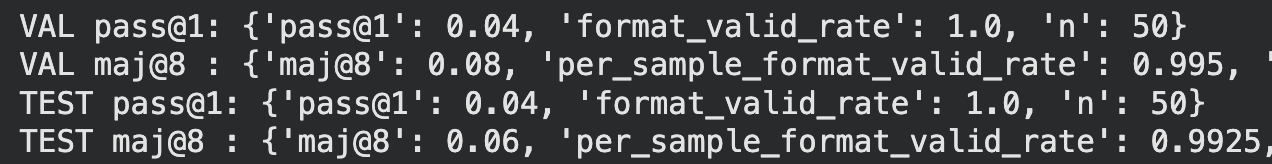